In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
data_dir = "../data/removal_data_repl_interpol_6k"

## Inspect Metadata

In [3]:
df_summary = pd.read_csv("../data/beats_summary_frame.csv")
df_summary.shape

(240012, 14)

In [4]:
df_summary['subject'].nunique(), df_summary['subject'].max()

(20001, np.int64(20000))

In [5]:
df_all_meta = pd.read_csv("../data/exams.csv")
df_all_meta.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5


In [6]:
df_meta_16 = df_all_meta[df_all_meta['trace_file'] == "exams_part16.hdf5"].copy()
df_meta_16.reset_index(drop=True, inplace=True)
df_meta_16.shape

(20000, 15)

In [7]:
df_meta_16.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1719487,36,True,48.075348,False,False,False,False,False,False,743857,False,1.049314,True,exams_part16.hdf5
1,1733991,66,False,40.656740,False,False,False,False,False,False,22622,NaN,NaN,False,exams_part16.hdf5
2,1801245,71,False,68.454320,False,False,False,False,False,False,825816,False,0.906849,False,exams_part16.hdf5
3,1805614,85,True,80.328300,False,False,False,False,False,False,1741484,NaN,NaN,False,exams_part16.hdf5
4,1718974,72,True,65.607850,False,False,False,False,False,False,995129,False,1.049314,False,exams_part16.hdf5


In [8]:
retained_subject_ids = df_summary[df_summary['retain_subject']]['subject'].values
df_meta_retained = df_meta_16[df_meta_16.index.isin(retained_subject_ids)].copy()

In [9]:
df_meta_retained.shape

(6044, 15)

In [10]:
df_meta_retained.head()

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1719487,36,True,48.075348,False,False,False,False,False,False,743857,False,1.049314,True,exams_part16.hdf5
1,1733991,66,False,40.656740,False,False,False,False,False,False,22622,NaN,NaN,False,exams_part16.hdf5
2,1801245,71,False,68.454320,False,False,False,False,False,False,825816,False,0.906849,False,exams_part16.hdf5
3,1805614,85,True,80.328300,False,False,False,False,False,False,1741484,NaN,NaN,False,exams_part16.hdf5
4,1718974,72,True,65.607850,False,False,False,False,False,False,995129,False,1.049314,False,exams_part16.hdf5


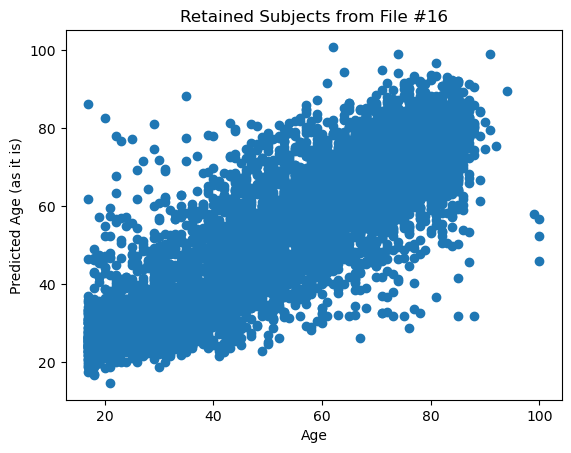

In [11]:
plt.title("Retained Subjects from File #16")
plt.xlabel("Age")
plt.ylabel("Predicted Age (as it is)")
plt.scatter(
    df_meta_retained['age'],
    df_meta_retained['nn_predicted_age'],
)
plt.show()

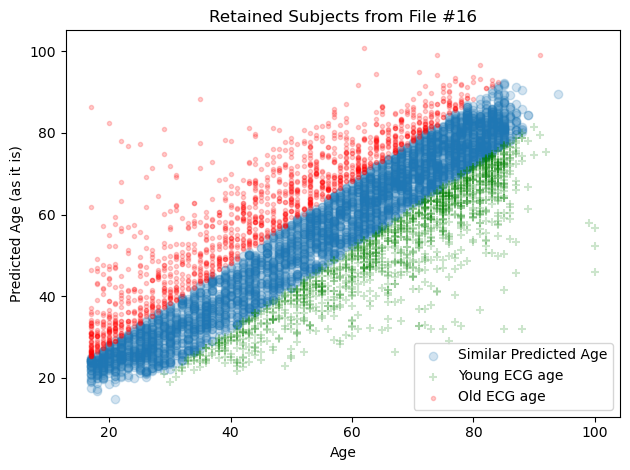

In [12]:
plt.title("Retained Subjects from File #16")
plt.xlabel("Age")
plt.ylabel("Predicted Age (as it is)")
young_filt = (df_meta_retained['age'] - df_meta_retained['nn_predicted_age'] >= 8)
as_is_filt = (abs(df_meta_retained['age'] - df_meta_retained['nn_predicted_age']) < 8)
old_filt = (df_meta_retained['nn_predicted_age'] - df_meta_retained['age'] >= 8)

plt.scatter(
    df_meta_retained[as_is_filt]['age'],
    df_meta_retained[as_is_filt]['nn_predicted_age'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df_meta_retained[young_filt]['age'],
    df_meta_retained[young_filt]['nn_predicted_age'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df_meta_retained[old_filt]['age'],
    df_meta_retained[old_filt]['nn_predicted_age'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [13]:
df_meta_retained.loc[:, 'pred_label'] = None
df_meta_retained.loc[young_filt, 'pred_label'] = 'young'
df_meta_retained.loc[as_is_filt, 'pred_label'] = 'neutral'
df_meta_retained.loc[old_filt, 'pred_label'] = 'old'

In [14]:
df_meta_retained['pred_label'].value_counts()

pred_label
neutral    3403
old        1358
young      1283
Name: count, dtype: int64

In [15]:
df_meta_retained['normal_ecg'].value_counts()

normal_ecg
False    3259
True     2785
Name: count, dtype: int64

In [16]:
df = pd.read_csv(f"{data_dir}/all_subjects_and_pixels_12pixels_6k_sub.csv")
df.shape

(2115400, 5)

In [17]:
df_exam_ids = pd.read_csv("../data/average_beat_metadata.csv")
df_exam_ids.head()

,exam_id,data_arr_idx,start_beat,end_beat,channel_used
0,1750214,0,1893,2358,0
1,1688724,1,1928,2288,1
2,1771393,2,1939,2266,0
3,1793030,3,1934,2275,0
4,1717689,4,1973,2197,1


In [18]:
df_exam_ids.shape

(6044, 5)

In [19]:
subject_exam_id = {}
for idx, exam_id in zip(df_exam_ids.index, df_exam_ids['exam_id']):
    subject_exam_id[idx] = exam_id

exam_id_age = {}
for exam_id, age in zip(df_meta_retained['exam_id'].values, df_meta_retained['age'].values):
    exam_id_age[exam_id] = age

print("number of subject ids in mapping")
print(len(subject_exam_id))

print("How many common subjects in replace metadata and average beat metadata:")
print(len(set(df['subject'].unique()).intersection(subject_exam_id.keys())))
print("\n")

df.loc[:, 'exam_id'] = df.index.map(subject_exam_id)
df.loc[:, 'age'] = df.exam_id.map(exam_id_age)
df.info()

number of subject ids in mapping
6044
How many common subjects in replace metadata and average beat metadata:
6044


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115400 entries, 0 to 2115399
Data columns (total 7 columns):
 #   Column              Dtype  
---  ------              -----  
 0   start_pixel         int64  
 1   subject             int64  
 2   raw_prediction      float64
 3   replace_prediction  float64
 4   replace_area        float64
 5   exam_id             float64
 6   age                 float64
dtypes: float64(5), int64(2)
memory usage: 113.0 MB


In [26]:
df[df['age'].isna()]['exam_id'].unique()

array([1750214., 1688724., 1771393., ..., 1984896., 1875951.,      nan],
      shape=(4249,))

In [27]:
for key, value in subject_exam_id.items():
    if value == 1750214:
        print(key, value)

0 1750214


In [ ]:
# Correlation of replaced area with diffrence in prediction
plt.xlabel("Replaced Area")
plt.ylabel("Absolute Difference in Age Predictions")
plt.scatter(df['replace_area'], abs(df['raw_prediction'] - df['replace_prediction']))
plt.show()

In [ ]:
x_arr = [30, 47]

In [ ]:
pixel = 2048
plt.scatter(
    df[df['start_pixel'] == pixel]['raw_prediction'],
    df[df['start_pixel'] == pixel]['replace_prediction']
)
plt.xlabel("Orig Prediction")
plt.ylabel(f"Removed pixels at {pixel} prediction")
plt.plot(x_arr, x_arr, c='red')
plt.show()

In [ ]:
df[~df.age.isna()]['subject'].nunique()

In [ ]:
pixel = 2048
plt.title("Retained Subjects from File #16; 12 pixels removed")
plt.xlabel("Raw Prediction")
plt.ylabel(f"Predicted Age (removed at {pixel})")
young_filt = (df['age'] - df['raw_prediction'] >= 8)
as_is_filt = (abs(df['age'] - df['raw_prediction']) < 8)
old_filt = (df['raw_prediction'] - df['age'] >= 8)

pixel_start_filt = (df['start_pixel'] == pixel)

plt.scatter(
    df[as_is_filt & pixel_start_filt]['age'],
    df[as_is_filt & pixel_start_filt]['replace_prediction'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df[young_filt & pixel_start_filt]['age'],
    df[young_filt & pixel_start_filt]['replace_prediction'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df[old_filt & pixel_start_filt]['age'],
    df[old_filt & pixel_start_filt]['replace_prediction'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [ ]:
pixel = 2048
plt.title("Retained Subjects from File #16; 12 pixels removed")
plt.xlabel("Raw Prediction")
plt.ylabel(f"Predicted Age (removed at {pixel})")
young_filt = (df['age'] - df['raw_prediction'] >= 8)
as_is_filt = (abs(df['age'] - df['raw_prediction']) < 8)
old_filt = (df['raw_prediction'] - df['age'] >= 8)

pixel_start_filt = (df['start_pixel'] == pixel)

plt.scatter(
    df[as_is_filt & pixel_start_filt]['age'],
    df[as_is_filt & pixel_start_filt]['raw_prediction'],
    label='Similar Predicted Age',
    alpha=0.2
)

plt.scatter(
    df[young_filt & pixel_start_filt]['age'],
    df[young_filt & pixel_start_filt]['raw_prediction'],
    label='Young ECG age',
    c='green',
    alpha=0.2,
    marker='+'
    
)

plt.scatter(
    df[old_filt & pixel_start_filt]['age'],
    df[old_filt & pixel_start_filt]['raw_prediction'],
    label='Old ECG age',
    c='red',
    alpha=0.2,
    marker='.'
)
plt.legend()
plt.tight_layout()
plt.savefig("selected_subjects_age_vs_orig_predicted.png")
plt.show()

In [ ]:
pixel = 1950
plt.scatter(
    df[df['start_pixel'] == pixel]['raw_prediction'],
    df[df['start_pixel'] == pixel]['replace_prediction']
)

In [ ]:
pixel = 2150
plt.scatter(
    df[df['start_pixel'] == pixel]['raw_prediction'],
    df[df['start_pixel'] == pixel]['replace_prediction']
)

In [ ]:
df_subjects = pd.read_csv("../data/beats_summary_frame.csv")
df_subjects.shape

In [ ]:
df_subjects_ = df_subjects[['subject', 'retain_subject', 'new_subject_id']]
df_subjects_ = df_subjects_.drop_duplicates()
df_subjects_['retain_subject'].sum()

In [ ]:
df['subject'].nunique()

In [ ]:
exam_ids = np.load("../data/one_beat_ids_part16.npy")
len(exam_ids)